# Store Segmentation

This notebook develops a store segmentation analysis for the close-to-expiration markdown project.

The workflow includes feature engineering, standardisation, hierarchical clustering, K-Means clustering and PCA visualisation.

> **Data availability:** The original project datasets are not included in this public repository. Place the processed input files in `../data/` using the filenames referenced below.


## Load and Merge Product and Store Data


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")

df1 = pd.read_excel(DATA_DIR / "products_ML.xlsx")
df2 = pd.read_excel(DATA_DIR / "cleaned_store.xlsx")


In [ ]:

df_cluster = pd.merge(df1, df2, on='idstore', how='left')

In [ ]:
cols = df_cluster.columns.tolist()
if 'sold' in cols:
    cols.remove('sold')
    cols.append('sold')
    df_cluster = df_cluster[cols]

display(df_cluster.head())

,idstore,sku,brand,oldpvp,new_pvp,discount,labelqty,weight (g),Payment_method,Margin (%),...,perc_expiring_sku,expiring_date,labelling_date,sell_date,days_until_expiration,days_to_sell,type,selling_square_ft,district,sold
0,9,168,2,0.99,0.49,0.51,1,193.0,,20,...,0.067039,2021-10-18,2021-10-06,NaT,12,NaN,Large,3673.0,Porto,0
1,99,223,7,0.99,0.49,0.51,1,107.0,,20,...,0.125000,2021-10-28,2021-10-27,NaT,1,NaN,Medium,8415.0,Coimbra,0
2,99,223,7,0.99,0.49,0.51,1,107.0,,20,...,0.125000,2021-10-28,2021-10-27,NaT,1,NaN,Medium,8415.0,Coimbra,0
3,18,223,7,0.99,0.49,0.51,1,107.0,Card,20,...,0.250000,2021-10-14,2021-10-12,2021-10-14,2,2.0,Large,12373.0,Leiria,1
4,18,223,7,0.99,0.49,0.51,1,107.0,Cash,20,...,0.250000,2021-10-14,2021-10-12,2021-10-14,2,2.0,Large,12373.0,Leiria,1


## Feature Definition


We selected features considered relevant to the business question: store size, average expiration risk, average discount and average margin. Additional variables were created to evaluate segment performance.


In [ ]:
perfil_lojas= df_cluster.groupby('idstore').agg(
    tamanho = ('selling_square_ft', 'first'),
    total_sku = ('sku', 'count'),
    avg_risco_expiry = ('perc_expiring_sku', 'mean'),
    avg_dias_expiry = ('days_until_expiration', 'mean'),
    avg_desconto = ('discount', 'mean'),
    ttl_vendidos = ('sold', 'sum'),
    avg_margem = ('Margin (%)', 'mean'),
).reset_index()

Additional features were engineered to support the evaluation of segment performance.


In [ ]:
perfil_lojas['taxa_conversao'] = perfil_lojas['ttl_vendidos'] / perfil_lojas['total_sku']

In [ ]:
avg_weekly_labeled = (
    df1.groupby(['idstore', pd.Grouper(key='labelling_date', freq='W-MON')])['sku']
    .count()                         # Step 1: Count total items per week
    .groupby('idstore')             # Step 2: Switch context back to just store_id
    .mean()                          # Compute average across those weekly counts
    .reset_index(name='avg_weekly_labeled_volume')
)

In [ ]:
perfil_lojas = pd.merge(perfil_lojas, avg_weekly_labeled, on='idstore', how='left').fillna(0)

## Model Development


In [ ]:
X = perfil_lojas[['tamanho', 'avg_risco_expiry', 'avg_desconto', 'avg_margem']]
X

,tamanho,avg_risco_expiry,avg_desconto,avg_margem
0,4762.0,0.447496,0.342250,15.022917
1,12358.0,0.375115,0.324469,15.712291
2,16159.0,0.346032,0.301029,16.431429
3,17903.0,0.196993,0.305130,16.562771
4,16179.0,0.363834,0.301619,15.844799
...,...,...,...,...
327,115.0,0.053030,0.500000,16.000000
328,1004.0,0.333333,0.300000,18.000000
329,3164.0,0.200000,0.300000,20.000000
330,215.0,0.333333,0.300000,19.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[-0.04379211,  0.76606631,  1.06773882, -1.044506  ],
       [ 1.49977128,  0.14189394,  0.5754277 , -0.20783711],
       [ 2.2721626 , -0.10889828, -0.07359631,  0.66495559],
       ...,
       [-0.36851753, -1.36818543, -0.1020753 ,  4.9960058 ],
       [-0.96777615, -0.21840151, -0.1020753 ,  3.78234081],
       [-0.56075173, -2.84342473,  5.43550632,  0.14134583]])

### Dendrogram
A dendrogram was used to help assess the appropriate number of clusters. Four clusters were selected for the segmentation.


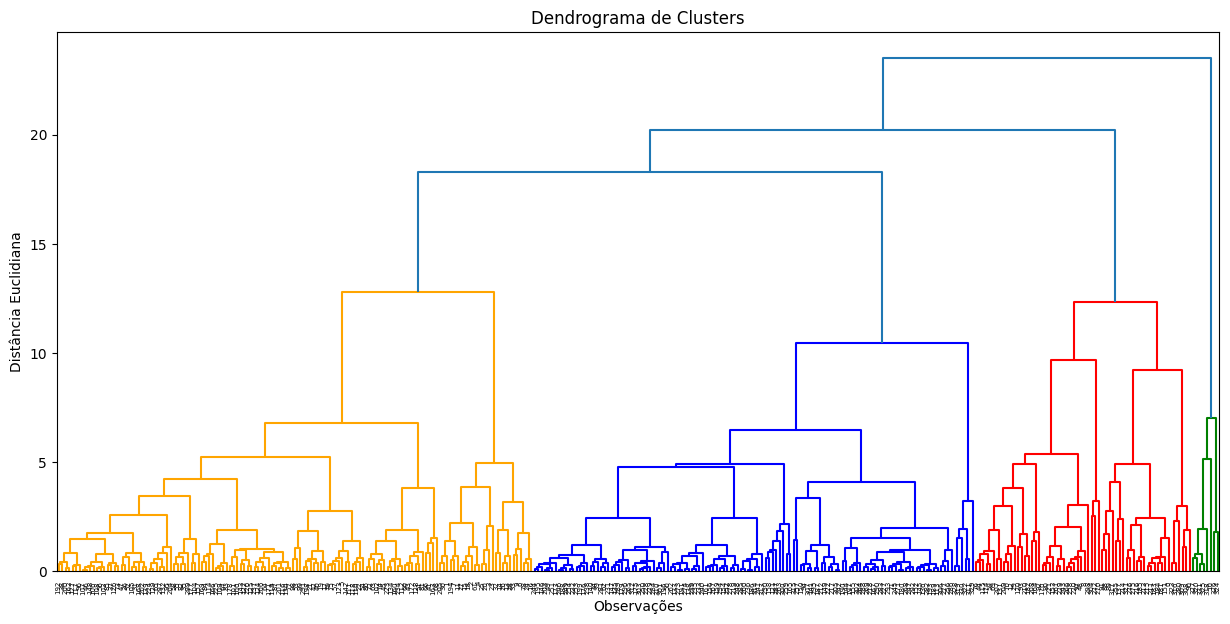

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette
import matplotlib.pyplot as plt

linked = linkage(X, method='ward')


requested_colors = ['#FFA500', '#0000FF', '#FF0000', '#008000'] # Hex codes for Orange, Blue, Red, Green


set_link_color_palette(requested_colors)

plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrograma de Clusters')
plt.xlabel('Observações')
plt.ylabel('Distância Euclidiana')
plt.show()

set_link_color_palette(None)

### K-Means++
K-Means++ was used to perform the store segmentation with four clusters.


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_ID = kmeans.fit_predict(X)

perfil_lojas['cluster_ID'] = cluster_ID

print("K-Means clustering with 4 clusters fitted successfully.")

K-Means clustering with 4 clusters fitted successfully.


### PCA
PCA was used to visualise the distribution of the clusters in a reduced-dimensional space.


In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.express.colors as px_colors
import pandas as pd

pca_kmeans_3d = PCA(n_components=3)
X_pca_kmeans_3d = pca_kmeans_3d.fit_transform(X)

perfil_lojas['pca_kmeans_3d_1'] = X_pca_kmeans_3d[:, 0]
perfil_lojas['pca_kmeans_3d_2'] = X_pca_kmeans_3d[:, 1]
perfil_lojas['pca_kmeans_3d_3'] = X_pca_kmeans_3d[:, 2]


custom_colors = ['#0000FF', '#FFA500', '#008000', '#FF0000']

cluster_order = ['1', '2', '3', '4']
cluster_categorical_type = pd.CategoricalDtype(categories=cluster_order, ordered=True)


color_map = {
    '1': '#0000FF',
    '2': '#008000',
    '3': '#FFA500',
    '4': '#FF0000'
}

fig_kmeans_3d = px.scatter_3d(perfil_lojas,
                    x='pca_kmeans_3d_1',
                    y='pca_kmeans_3d_2',
                    z='pca_kmeans_3d_3',

                    color=((perfil_lojas['cluster_ID'] + 1).astype(str).astype(cluster_categorical_type)),
                    color_discrete_map=color_map,
                    hover_name='idstore',
                    title='3D PCA of K-Means Store Clusters',
                    labels={'color': 'Cluster ID'},
                    category_orders={'color': cluster_order})

fig_kmeans_3d.show()

## Cluster Summary


The clusters were characterised using selected features to support interpretation and the conclusions presented in the project report.


In [ ]:
cluster_summary = perfil_lojas.groupby('cluster_ID').agg(
    avg_tamanho=('tamanho', 'mean'),
    avg_risco_expiry=('avg_risco_expiry', 'mean'),
    avg_desconto=('avg_desconto', 'mean'),
    avg_margem=('avg_margem', 'mean'),
    avg_taxa_conversao=('taxa_conversao', 'mean'),
    avg_dias_expiry=('avg_dias_expiry', 'mean'),
    unique_stores=('idstore', 'nunique'),
    avg_weekly_labeled=('avg_weekly_labeled_volume', 'mean')
)

print(cluster_summary)

             avg_tamanho  avg_risco_expiry  avg_desconto  avg_margem  \
cluster_ID                                                             
0            2607.403756          0.392852      0.300196   16.040078   
1            2897.625000          0.053931      0.489176   16.332341   
2           12050.443038          0.377895      0.299470   15.939819   
3            3812.140625          0.159764      0.290961   14.590421   

            avg_taxa_conversao  avg_dias_expiry  unique_stores  \
cluster_ID                                                       
0                     0.520130         1.541088            213   
1                     0.429106         7.068529              8   
2                     0.524342         1.441919             79   
3                     0.412904         0.975932             32   

            avg_weekly_labeled  
cluster_ID                      
0                    90.780986  
1                     7.250000  
2                   118.975949  
3    

In [ ]:
centroids = kmeans.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids)

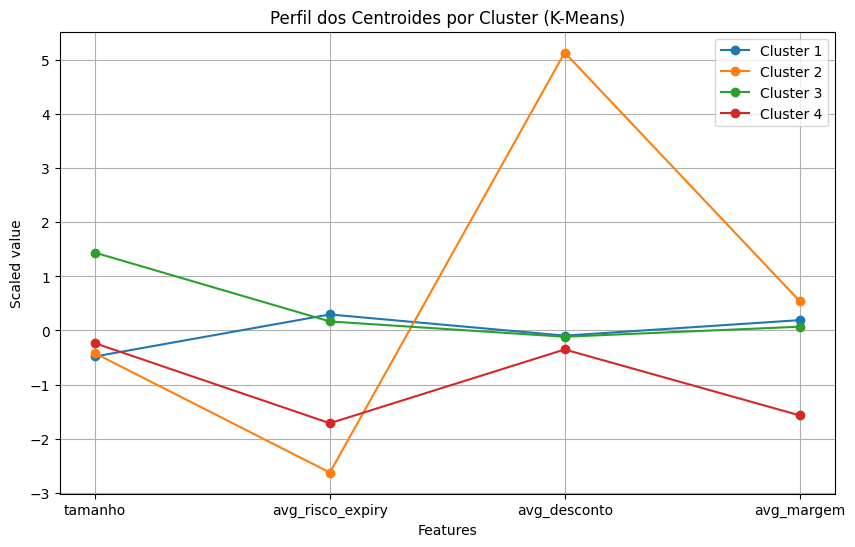

In [ ]:
cluster_ids = np.arange(1, centroids.shape[0] + 1)
feature_names = ['tamanho', 'avg_risco_expiry', 'avg_desconto', 'avg_margem']

plt.figure(figsize=(10, 6))

# Em vez de iterar pelas features, iteramos por cada cluster (linha da matriz centroids)
for c_idx, cluster_id in enumerate(cluster_ids):
    plt.plot(feature_names, centroids[c_idx, :], marker='o', label=f'Cluster {cluster_id}')

plt.title('Perfil dos Centroides por Cluster (K-Means)')
plt.xlabel('Features')
plt.ylabel('Scaled value')
plt.legend()
plt.grid(True)
plt.show()